In [28]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from scipy.stats import pearsonr

In [29]:
pip seaborn

ERROR: unknown command "seaborn" - maybe you meant "search"
Note: you may need to restart the kernel to use updated packages.


In [30]:
df = pd.read_csv("/Users/herlinaherlina/Downloads/supply_chain_data.csv")

In [31]:
df.head()

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Product type             100 non-null    object 
 1   SKU                      100 non-null    object 
 2   Price                    100 non-null    float64
 3   Availability             100 non-null    int64  
 4   Number of products sold  100 non-null    int64  
 5   Revenue generated        100 non-null    float64
 6   Customer demographics    100 non-null    object 
 7   Stock levels             100 non-null    int64  
 8   Lead times               100 non-null    int64  
 9   Order quantities         100 non-null    int64  
 10  Shipping times           100 non-null    int64  
 11  Shipping carriers        100 non-null    object 
 12  Shipping costs           100 non-null    float64
 13  Supplier name            100 non-null    object 
 14  Location                 10

In [33]:
#Hitung total nilai yang hilang per kolom
missing_counts = df.isnull().sum()

# Hitung persentase nilai yang hilang per kolom
missing_percentage = (missing_counts / len(df)) * 100

# Gabungkan hasil menjadi DataFrame
missing_summary = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percentage (%)': missing_percentage
})

print(missing_summary)

                         Missing Count  Missing Percentage (%)
Product type                         0                     0.0
SKU                                  0                     0.0
Price                                0                     0.0
Availability                         0                     0.0
Number of products sold              0                     0.0
Revenue generated                    0                     0.0
Customer demographics                0                     0.0
Stock levels                         0                     0.0
Lead times                           0                     0.0
Order quantities                     0                     0.0
Shipping times                       0                     0.0
Shipping carriers                    0                     0.0
Shipping costs                       0                     0.0
Supplier name                        0                     0.0
Location                             0                 

In [34]:
df.describe()

,Price,Availability,Number of products sold,Revenue generated,Stock levels,Lead times,Order quantities,Shipping times,Shipping costs,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Defect rates,Costs
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000
mean,49.462461,48.400000,460.990000,5776.048187,47.770000,15.960000,49.220000,5.750000,5.548149,17.080000,567.840000,14.77000,47.266693,2.277158,529.245782
std,31.168193,30.743317,303.780074,2732.841744,31.369372,8.785801,26.784429,2.724283,2.651376,8.846251,263.046861,8.91243,28.982841,1.461366,258.301696
min,1.699976,1.000000,8.000000,1061.618523,0.000000,1.000000,1.000000,1.000000,1.013487,1.000000,104.000000,1.00000,1.085069,0.018608,103.916248
25%,19.597823,22.750000,184.250000,2812.847151,16.750000,8.000000,26.000000,3.750000,3.540248,10.000000,352.000000,7.00000,22.983299,1.009650,318.778455
50%,51.239831,43.500000,392.500000,6006.352023,47.500000,17.000000,52.000000,6.000000,5.320534,18.000000,568.500000,14.00000,45.905622,2.141863,520.430444
75%,77.198228,75.000000,704.250000,8253.976921,73.000000,24.000000,71.250000,8.000000,7.601695,25.000000,797.000000,23.00000,68.621026,3.563995,763.078231
max,99.171329,100.000000,996.000000,9866.465458,100.000000,30.000000,96.000000,10.000000,9.929816,30.000000,985.000000,30.00000,99.466109,4.939255,997.413450


In [35]:
df.to_csv("/Users/herlinaherlina/Downloads/Project_Supply_Chain_Analyst.csv")

In [36]:
total_revenue = df["Revenue generated"].sum()
print(f"Total revenue semua produk: ${total_revenue:,.2f}")
print("")

Total revenue semua produk: $577,604.82



In [37]:
rata_rata_harga = df["Price"].mean()
print(f"Rata-rata harga produk: ${rata_rata_harga:.2f}")
print("")

Rata-rata harga produk: $49.46



In [38]:
print("--- Total revenue per jenis produk ---")
revenue_per_jenis = df.groupby("Product type")["Revenue generated"].sum()
print(revenue_per_jenis)
print("")

--- Total revenue per jenis produk ---
Product type
cosmetics    161521.265999
haircare     174455.390605
skincare     241628.162133
Name: Revenue generated, dtype: float64



In [39]:
print("--- Revenue per jenis produk (diurutkan) ---")
revenue_per_jenis_urut = revenue_per_jenis.sort_values(ascending=False)
print(revenue_per_jenis_urut)
print("")


--- Revenue per jenis produk (diurutkan) ---
Product type
skincare     241628.162133
haircare     174455.390605
cosmetics    161521.265999
Name: Revenue generated, dtype: float64



In [40]:
print("--- 5 SKU dengan revenue tertinggi ---")
top_5 = df.sort_values("Revenue generated", ascending=False).head(5)
print(top_5[["SKU", "Product type", "Revenue generated"]])
print("")

--- 5 SKU dengan revenue tertinggi ---
      SKU Product type  Revenue generated
51  SKU51     haircare        9866.465458
38  SKU38    cosmetics        9692.318040
31  SKU31     skincare        9655.135103
90  SKU90     skincare        9592.633570
2    SKU2     haircare        9577.749626



In [41]:
print("--- Jumlah SKU per supplier ---")
print(df["Supplier name"].value_counts())
print("")

--- Jumlah SKU per supplier ---
Supplier name
Supplier 1    27
Supplier 2    22
Supplier 5    18
Supplier 4    18
Supplier 3    15
Name: count, dtype: int64



In [42]:
print("--- Produk dengan defect rate lebih dari 4% ---")
defect_tinggi = df[df["Defect rates"] > 4]
print(defect_tinggi[["SKU", "Product type", "Defect rates"]])
print("")

--- Produk dengan defect rate lebih dari 4% ---
      SKU Product type  Defect rates
1    SKU1     skincare      4.854068
2    SKU2     haircare      4.580593
3    SKU3     skincare      4.746649
20  SKU20     skincare      4.231417
40  SKU40     skincare      4.213269
42  SKU42     skincare      4.939255
50  SKU50    cosmetics      4.754801
55  SKU55     haircare      4.548920
61  SKU61     haircare      4.367471
65  SKU65     skincare      4.911096
73  SKU73    cosmetics      4.620546
78  SKU78     haircare      4.096881
82  SKU82     skincare      4.137877
84  SKU84     haircare      4.843457
93  SKU93     haircare      4.165782



In [43]:
print("--- Total revenue per jenis produk (diurutkan) ---")
revenue_per_jenis = df.groupby("Product type")["Revenue generated"].sum()
revenue_per_jenis_urut = revenue_per_jenis.sort_values(ascending=False)
print(revenue_per_jenis_urut)
print("")


--- Total revenue per jenis produk (diurutkan) ---
Product type
skincare     241628.162133
haircare     174455.390605
cosmetics    161521.265999
Name: Revenue generated, dtype: float64



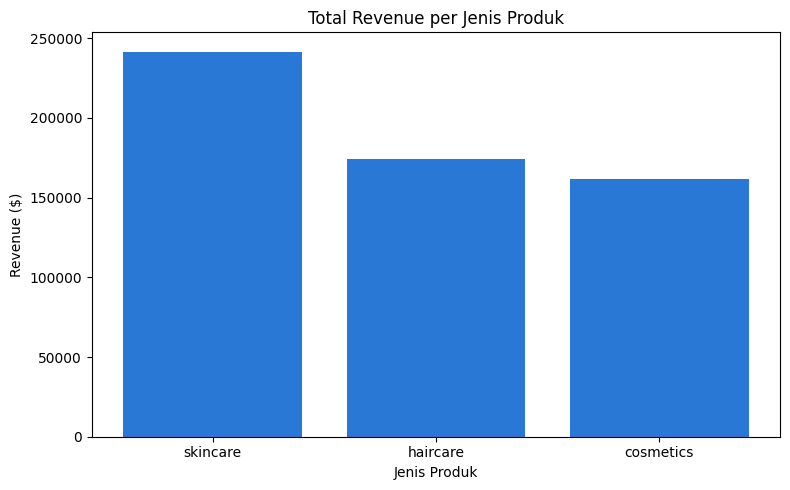

Grafik 1 tersimpan: chart_1_revenue_per_jenis.png



In [45]:
plt.figure(figsize=(8, 5))
plt.bar(revenue_per_jenis_urut.index, revenue_per_jenis_urut.values, color="#2a78d6")
plt.title("Total Revenue per Jenis Produk")
plt.xlabel("Jenis Produk")
plt.ylabel("Revenue ($)")
plt.tight_layout()
plt.show()
print("Grafik 1 tersimpan: chart_1_revenue_per_jenis.png")
print("")

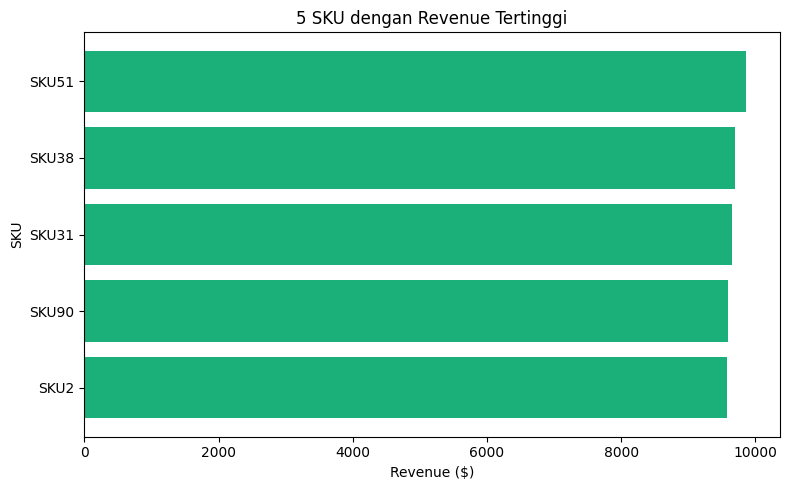

Grafik 2 tersimpan: chart_2_top5_sku.png



In [47]:
plt.figure(figsize=(8, 5))
plt.barh(top_5["SKU"], top_5["Revenue generated"], color="#1baf7a")
plt.title("5 SKU dengan Revenue Tertinggi")
plt.xlabel("Revenue ($)")
plt.ylabel("SKU")
plt.gca().invert_yaxis()  # supaya SKU rank #1 ada di atas
plt.tight_layout()
plt.show()
print("Grafik 2 tersimpan: chart_2_top5_sku.png")
print("")

In [49]:
print("--- Jumlah SKU per supplier ---")
jumlah_per_supplier = df["Supplier name"].value_counts()
print(jumlah_per_supplier)
print("")

print("--- Jumlah SKU per hasil inspeksi kualitas ---")
jumlah_per_inspeksi = df["Inspection results"].value_counts()
print(jumlah_per_inspeksi)
print("")

--- Jumlah SKU per supplier ---
Supplier name
Supplier 1    27
Supplier 2    22
Supplier 5    18
Supplier 4    18
Supplier 3    15
Name: count, dtype: int64

--- Jumlah SKU per hasil inspeksi kualitas ---
Inspection results
Pending    41
Fail       36
Pass       23
Name: count, dtype: int64



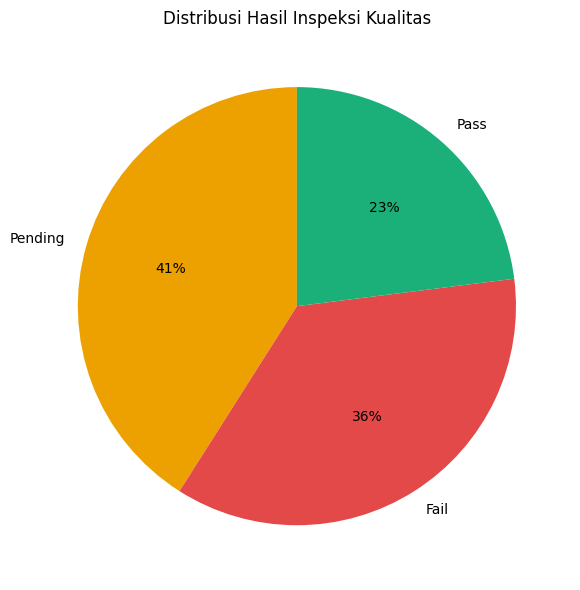

Grafik 3 tersimpan: chart_3_inspeksi.png



In [51]:
warna_inspeksi = {"Pass": "#1baf7a", "Fail": "#e34948", "Pending": "#eda100"}
warna_list = [warna_inspeksi.get(label, "#898781") for label in jumlah_per_inspeksi.index]

plt.figure(figsize=(6, 6))
plt.pie(
    jumlah_per_inspeksi.values,
    labels=jumlah_per_inspeksi.index,
    autopct="%1.0f%%",   # menampilkan persentase
    colors=warna_list,
    startangle=90
)
plt.title("Distribusi Hasil Inspeksi Kualitas")
plt.tight_layout()
plt.show()
print("Grafik 3 tersimpan: chart_3_inspeksi.png")
print("")


--- Produk dengan defect rate lebih dari 4% ---
      SKU Product type  Defect rates
1    SKU1     skincare      4.854068
2    SKU2     haircare      4.580593
3    SKU3     skincare      4.746649
20  SKU20     skincare      4.231417
40  SKU40     skincare      4.213269
42  SKU42     skincare      4.939255
50  SKU50    cosmetics      4.754801
55  SKU55     haircare      4.548920
61  SKU61     haircare      4.367471
65  SKU65     skincare      4.911096
73  SKU73    cosmetics      4.620546
78  SKU78     haircare      4.096881
82  SKU82     skincare      4.137877
84  SKU84     haircare      4.843457
93  SKU93     haircare      4.165782



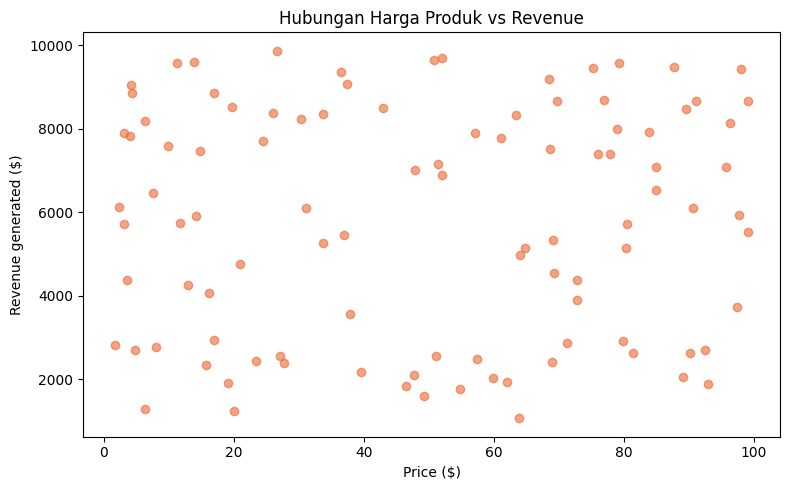

Grafik 4 tersimpan: chart_4_price_vs_revenue.png



In [53]:
print("--- Produk dengan defect rate lebih dari 4% ---")
defect_tinggi = df[df["Defect rates"] > 4]
print(defect_tinggi[["SKU", "Product type", "Defect rates"]])
print("")


# ==========================================================
# VISUALISASI 4: Scatter plot - Hubungan Price vs Revenue
# ==========================================================
# Scatter plot cocok untuk melihat apakah dua variabel angka
# punya hubungan/pola tertentu
plt.figure(figsize=(8, 5))
plt.scatter(df["Price"], df["Revenue generated"], alpha=0.6, color="#eb6834")
plt.title("Hubungan Harga Produk vs Revenue")
plt.xlabel("Price ($)")
plt.ylabel("Revenue generated ($)")
plt.tight_layout()
plt.show()
print("Grafik 4 tersimpan: chart_4_price_vs_revenue.png")
print("")

In [55]:
revenue_per_jenis_urut.to_csv("/Users/herlinaherlina/Downloads/Project_Supply_Chain.csv")
print("Selesai! Hasil sudah disimpan ke hasil_revenue_per_jenis.csv")


Selesai! Hasil sudah disimpan ke hasil_revenue_per_jenis.csv
